# Apartado 2. Clasificador de comentarios en subreddits

En esta sección vamos a desarrollar y analizar distintos modelos de procesamiento del lenguaje para clasificación. Nuestro clasificador será capaz de recibir un comentario y predecir a que subreddit de los 6 seleccionados (books, jobs, LeagueOfLegends, RandomThoughts, travel, unpopopularopinion) pertenece el mensaje, estimando las probabilidades de pertenecer a cada uno de ellos.

Con el fin de obtener un modelo robusto e insesgado, vamos a realizar en primer lugar la división en conjunto de entrenamiento y validación.

Para ello utilizaremos los ficheros JSON limpios generados en el apartado anterior. Para la división vamos a utilizar una estrategia basada en hilos y no en comentarios individuales.

El ratio de división entre entrenamiento y validación, va a ser 70% y 30%, respectivamente.

Como ya hemos mencionado, con el fin de que nuestro modelo generalice correctamente y no memorice patrones concretos de un determinado hilo, todos los comentarios de un mismo hilo se asignará únicamente a uno de los dos conjuntos, o bien el de entrenamiento, o bien al de validación, pero nunca a ambos. En el apartado anterior hemos obtenido 59 hilos por cada subreddit, por lo que utilizaremos aproximadamente 41 hilos para entrenar y 18 para validar. Teniendo 20 comentarios por hilo, contaremos con un total de:
- 6 (subreddits) * 41 (hilos) * 20 (comentarios) = 4920 comentarios en el conjunto de entrenamiento
- 6 (subreddits) * 18 (hilos) * 20 (comentarios) = 2160 comentarios en el conjunto de validación

Es importante destacar que tanto el conjunto de datos original como el conjunto preprocesado mantienen exactamente el mismo número de comentarios. Esto se debe a que el proceso de preprocesamiento aplicado en esta práctica es únicamente de limpieza léxica, eliminando elementos como stopwords, URLs o menciones, pero sin eliminar comentarios ni modificar la estructura del corpus. Por tanto, la distribución de ejemplos se mantiene constante entre ambos conjuntos, lo que permite una comparación justa y directa entre modelos entrenados con datos originales y con datos limpios.

## Corpus preprocesado

In [ ]:
import json
import regex as re
import random

subreddits = ["limpio_books.json", "limpio_jobs.json", "limpio_LeagueOfLegends.json", "limpio_RandomThoughts.json",
			  "limpio_travel.json", "limpio_unpopularopinion.json"]

X_train_limpio, X_test_limpio = [], []
# Solo hace falta hacer la variable de salida una vez, ya que es el nombre del subreddit al que pertenecen y eso
# no cambia con el preprocesamiento
y_train, y_test = [], []

proporcion = 0.7

for subreddit in subreddits:
	with open(subreddit, "r", encoding="utf-8") as file:
		datos = json.load(file)

	# Obtenemos el nombre del subreddit, ya que será nuestra salida esperada "y"
	nombre = datos["subreddit"]

	# Extraemos todos los hilos pertenecientes al subreddit
	hilos = datos["submissions"]

	# Mezclamos los hilos para que la división sea aleatoria
	random.shuffle(hilos)

	# Como hemos calculado en la explicación, en base a los hilos que tengamos en cada subreddit, utilizaremos unos
	# para entrenamiento y otros para validación. Multiplicando por la proporcion obtendremos valores con decimales
	# por lo que lo pasamos a entero, ya que los índices son enteros.
	indice = int(len(hilos) * proporcion)

	# Extraemos los hilos que pertenecerán al conjunto de entrenamiento y los que pertenecerán a la validación
	hilos_train = hilos[:indice]
	hilos_test = hilos[indice:]

	# Guardamos el texto de los comentarios en el conjunto train, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_train:
		for comentario in hilo["comments"]:
			X_train_limpio.append(comentario["body"].lower())
			y_train.append(nombre)

	# Guardamos el texto de los comentarios en el conjunto test, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_test:
		for comentario in hilo["comments"]:
			X_test_limpio.append(comentario["body"].lower())
			y_test.append(nombre)

## Corpus original

In [ ]:
import json
import regex as re
import random

subreddits = ["completo_books.json", "completo_jobs.json", "completo_LeagueOfLegends.json", "completo_RandomThoughts.json",
			  "completo_travel.json", "completo_unpopularopinion.json"]

X_train_completo, X_test_completo = [], []

proporcion = 0.7

for subreddit in subreddits:
	with open(subreddit, "r", encoding="utf-8") as file:
		datos = json.load(file)

	# Obtenemos el nombre del subreddit, ya que será nuestra salida esperada "y"
	nombre = datos["subreddit"]

	# Extraemos todos los hilos pertenecientes al subreddit
	hilos = datos["submissions"]

	# Mezclamos los hilos para que la división sea aleatoria
	random.shuffle(hilos)

	# Como hemos calculado en la explicación, en base a los hilos que tengamos en cada subreddit, utilizaremos unos
	# para entrenamiento y otros para validación. Multiplicando por la proporcion obtendremos valores con decimales
	# por lo que lo pasamos a entero, ya que los índices son enteros.
	indice = int(len(hilos) * proporcion)

	# Extraemos los hilos que pertenecerán al conjunto de entrenamiento y los que pertenecerán a la validación
	hilos_train = hilos[:indice]
	hilos_test = hilos[indice:]

	# Guardamos el texto de los comentarios en el conjunto train, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_train:
		for comentario in hilo["comments"]:
			X_train_completo.append(comentario["body"].lower())

	# Guardamos el texto de los comentarios en el conjunto test, aplicándole un preprocesamiento, en este caso pasar el texto a minúsculas,
	# y el subreddit al que pertenece.
	for hilo in hilos_test:
		for comentario in hilo["comments"]:
			X_test_completo.append(comentario["body"].lower())

In [ ]:
# Comprobamos que el resultado obtenido es el que habíamos calculado previamente
print(f"Conjunto de entrenamiento: Hemos obtenido {len(X_train_limpio)} comentarios")
print(f"Conjunto de validación: Hemos obtenido {len(X_test_limpio)} comentarios")

Conjunto de entrenamiento: Hemos obtenido 4920 comentarios
Conjunto de validación: Hemos obtenido 2160 comentarios


In [ ]:
# Comprobamos que el resultado obtenido es el que habíamos calculado previamente
print(f"Conjunto de entrenamiento: Hemos obtenido {len(X_train_completo)} comentarios")
print(f"Conjunto de validación: Hemos obtenido {len(X_test_completo)} comentarios")

Conjunto de entrenamiento: Hemos obtenido 4920 comentarios
Conjunto de validación: Hemos obtenido 2160 comentarios


Una vez hemos obtenido los conjuntos necesarios para continuar con el siguiente paso donde usaremos distintos tipos de representación de textos para hacer esta clasificación.

## Clasificadores

En este apartado desarrollamos un clasificador automático capaz de predecir de qué subreddit proviene un comentario determinado.

Con el objetivo de comparar distintas aproximaciones de Procesamiento del Lenguaje Natural y analizar su comportamiento en esta tarea de clasificación multiclase, vamos a implementar tres sistemas diferentes.

El primer modelo se basa en representaciones TF-IDF junto con un clasificador lineal. Se trata de un enfoque clásico en PLN, donde los textos se convierten en vectores ponderados en función de la frecuencia de los términos, permitiendo entrenar un modelo lineal eficaz en espacios de alta dimensionalidad.

El segundo modelo está basado en embeddings de palabras, concretamente utilizando FastText. Este enfoque permite representar el texto mediante vectores densos que capturan relaciones semánticas entre palabras, lo que aporta una representación más rica que los métodos tradicionales basados en frecuencia.

El tercer modelo se fundamenta en arquitecturas Transformer, realizando fine-tuning sobre un modelo preentrenado como BERT. Este enfoque utiliza embeddings contextuales, lo que permite al modelo interpretar cada palabra en función de su contexto dentro de la frase, mejorando notablemente la capacidad de comprensión del lenguaje natural.

Con estos tres enfoques podremos comparar métodos tradicionales, modelos basados en embeddings y modelos basados en deep learning avanzado, analizando tanto su rendimiento como su capacidad de generalización en el conjunto de datos de nuestra práctica final.

## TF-IDF + LinearSVC

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,  accuracy_score, confusion_matrix

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Función auxiliar para visualizar la matriz de confusión en forma de gráfico para facilitar el análisis que realizaremos
def plot_matriz_confusion(matriz_confusion, titulo, ejes):
	plt.figure(figsize=(10,8))

	sns.heatmap(matriz_confusion, annot=True, xticklabels=ejes, yticklabels=ejes, cmap="Blues", fmt="d")

	plt.title(titulo, fontsize=15)
	plt.xlabel("Predicción")
	plt.ylabel("Valor real")
	plt.show()

In [ ]:
import pandas as pd

# Función auxiliar para visualizar la matriz de confusión en forma de gráfico para facilitar el análisis que realizaremos
def plot_informe_resultados(diccionario_informe, titulo):
	# Para tener en las filas los distintos subreddits y en las columnas las métricas
	df = pd.DataFrame(diccionario_informe).transpose()
	df = df.drop(["accuracy", "weighted avg", "macro avg"])

	plt.figure(figsize=(10,8))

	# Quito la métrica support también
	sns.heatmap(df.iloc[:, :-1], annot=True, cmap="Blues", fmt=".2f")

	plt.title(titulo, fontsize=15)
	plt.xlabel("Métricas")
	plt.ylabel("Subreddits")
	plt.show()

In [ ]:
# Añadimos una variable configuraciones para poder iterar sobre ella y aplicar más fácil todos los tipos de
# características pedidos en la práctica
configuraciones = {"Unigramas": (1, 1, "word"),
				   "Bigramas": (2, 2, "word"),
				   "Trigramas": (3, 3, "word"),
				   "Char-n-gramas": (3, 5, "char")}        # De 3 a 5 caracteres como hicimos en la práctica 6.2

# Añadimos otra variable para hacer con ambos conjuntos de entrenamiento y validación. Los completos, obtenidos directamente de reddit
# y los limpios, a los que hemos aplicado un preprocesado, eliminando mensajes que solo contienen URL, mensajes de bots, stopwords...
datasets = {"Completos": (X_train_completo, X_test_completo),
			"Limpios": (X_train_limpio, X_test_limpio)}

# Diccionario vacío para guardar todos los resultados y examinarlos más adelante
resultados = {}

# Iteramos por ambos conjuntos de entrenamiento
for datos, (X_train, X_test) in datasets.items():
	print(f"Dataset de datos {datos}\n")

	# Ahora iteramos por las configuraciones, creando el modelo correspondiente y mostramos los resultados
	for config, (minimo, maximo, tipo) in configuraciones.items():
		clf_tfidf = Pipeline([
		('vect', CountVectorizer(analyzer=tipo, ngram_range=(minimo, maximo))),
		('tf_idf', TfidfTransformer()),
		('clf', LinearSVC(random_state=23, tol=1e-5)),])

		clf_tfidf.fit(X_train, y_train)

		y_pred = clf_tfidf.predict(X_test)

		# Para que salga en formato diccionario y poder convertirlo a DataFrame y visualizarlo
		report = classification_report(y_test, y_pred, output_dict=True)
		matriz = confusion_matrix(y_test, y_pred)
		accuracy = accuracy_score(y_test, y_pred)

		etiquetas= clf_tfidf.classes_

		resultados[(datos, config)] = {"Accuracy": accuracy,
										"Informe de resultados": report,
										"Matriz de confusión": matriz,
										"Etiquetas": etiquetas}

		print("---------------------------------------------------------\n")
		print(f"Resultados para la configuración {config}")
		print(f"Accuracy = {accuracy}\n")

Dataset de datos Completos

---------------------------------------------------------

Resultados para la configuración Unigramas
Accuracy = 0.5606481481481481

---------------------------------------------------------

Resultados para la configuración Bigramas
Accuracy = 0.4083333333333333

---------------------------------------------------------

Resultados para la configuración Trigramas
Accuracy = 0.29907407407407405

---------------------------------------------------------

Resultados para la configuración Char-n-gramas
Accuracy = 0.5694444444444444

Dataset de datos Limpios

---------------------------------------------------------

Resultados para la configuración Unigramas
Accuracy = 0.5615740740740741

---------------------------------------------------------

Resultados para la configuración Bigramas
Accuracy = 0.36018518518518516

---------------------------------------------------------

Resultados para la configuración Trigramas
Accuracy = 0.20925925925925926

----------

Solo vamos a analizar las configuraciones con accuracy mayor que 0,5.

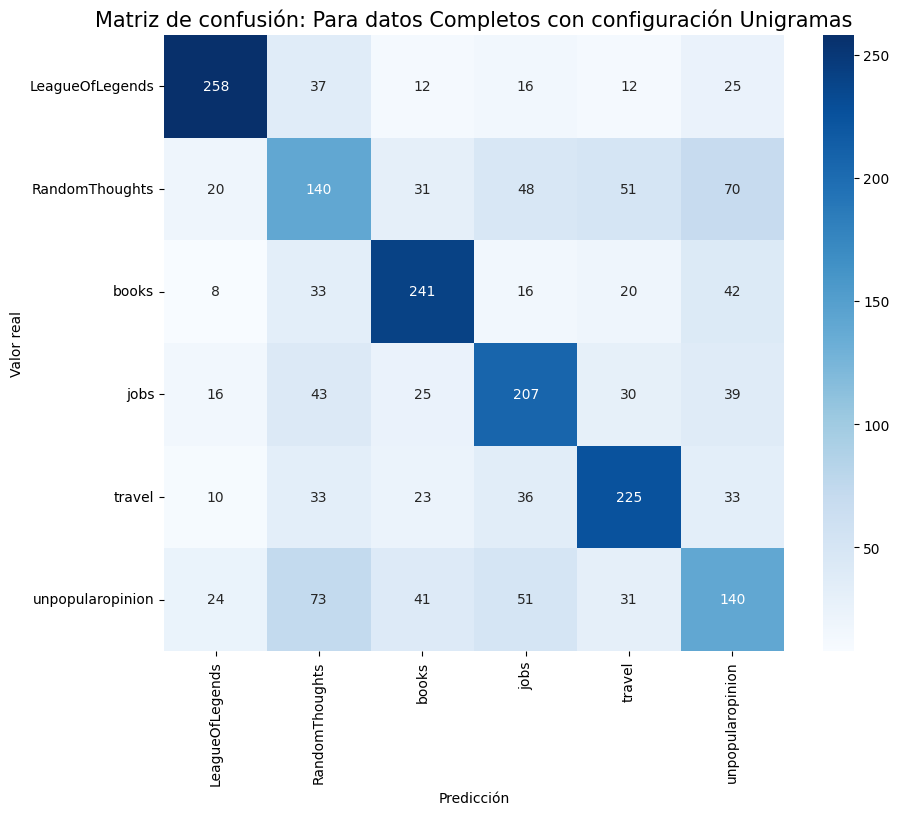

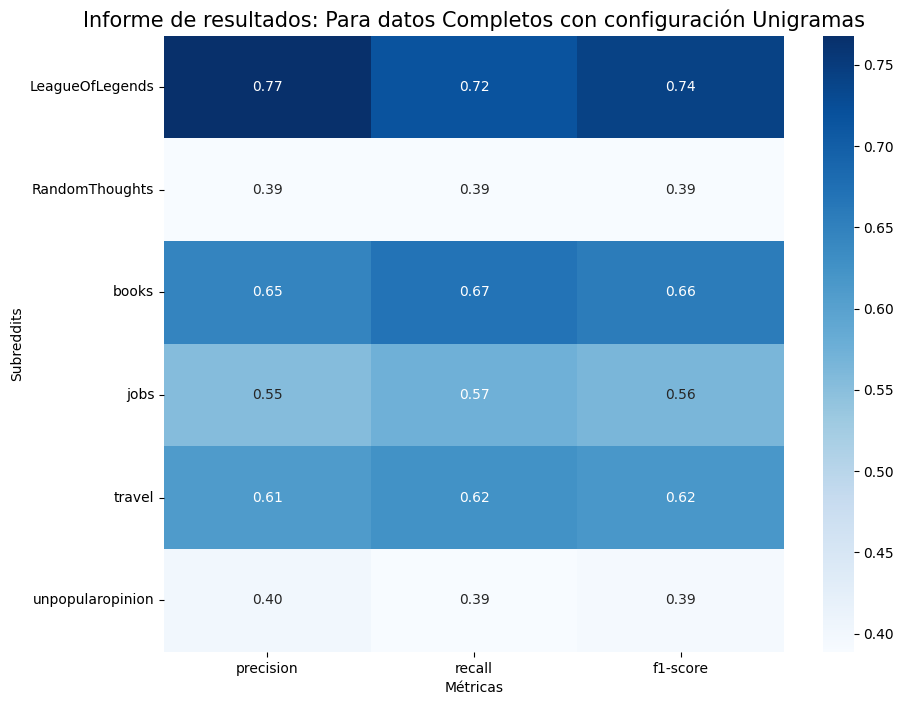

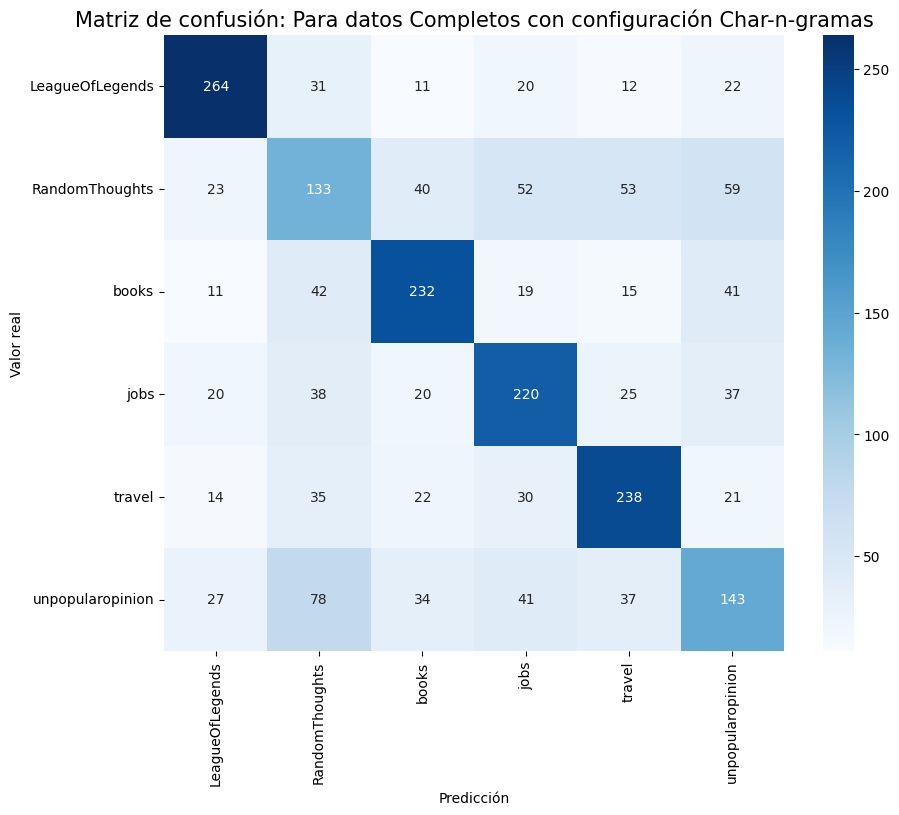

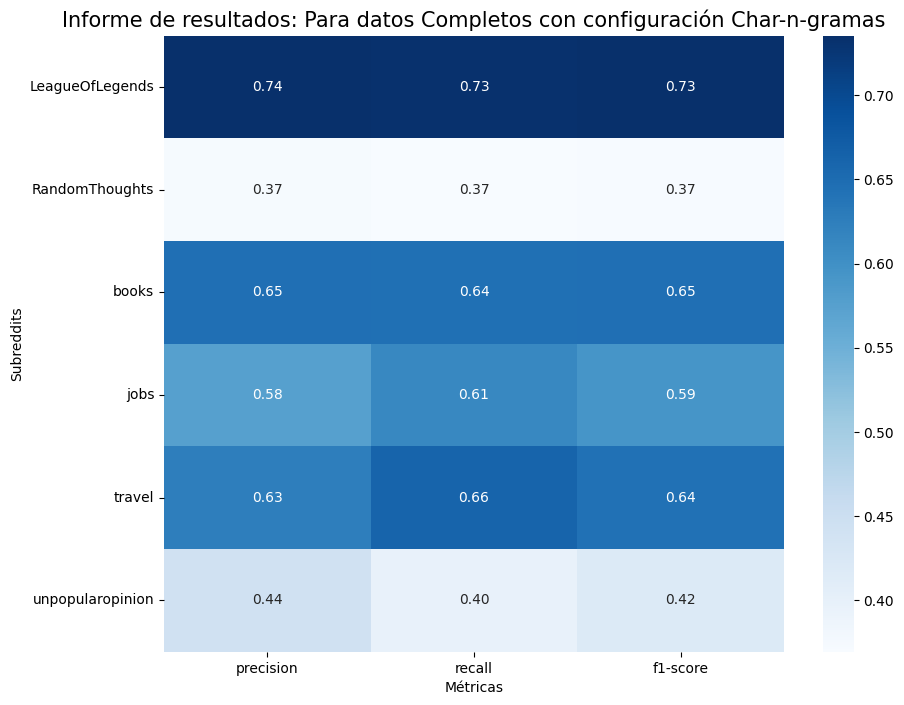

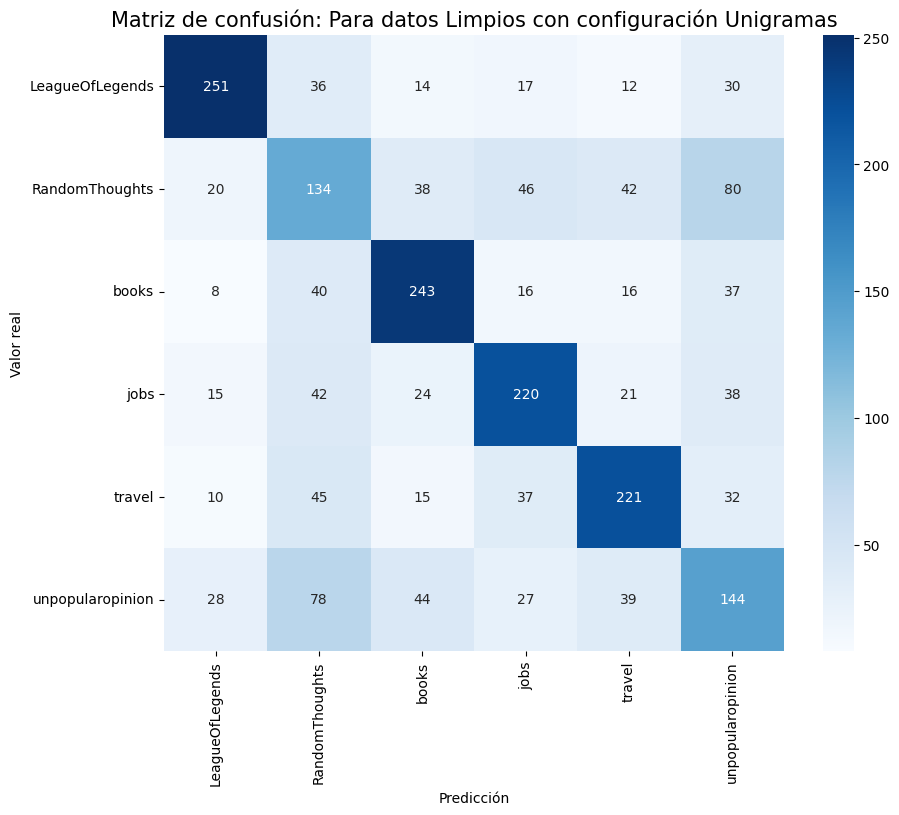

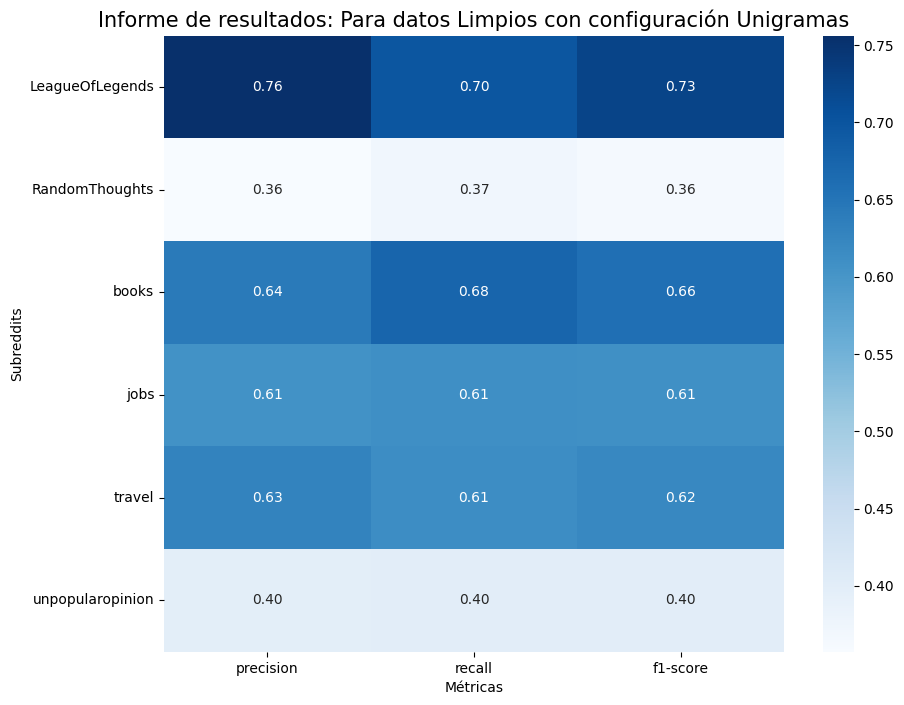

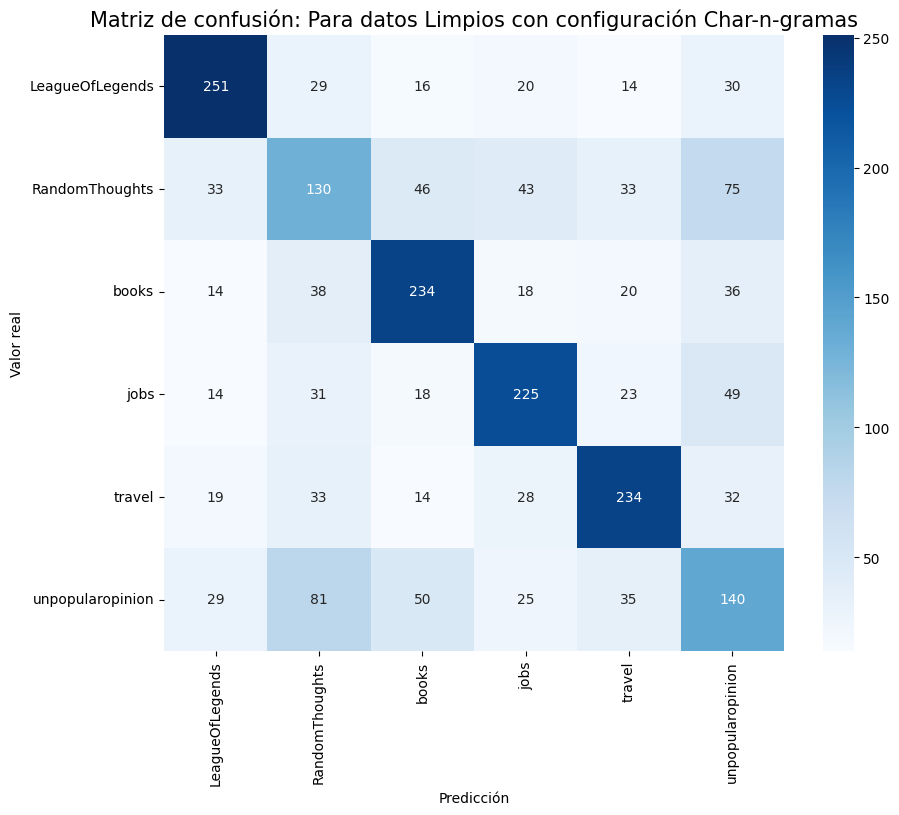

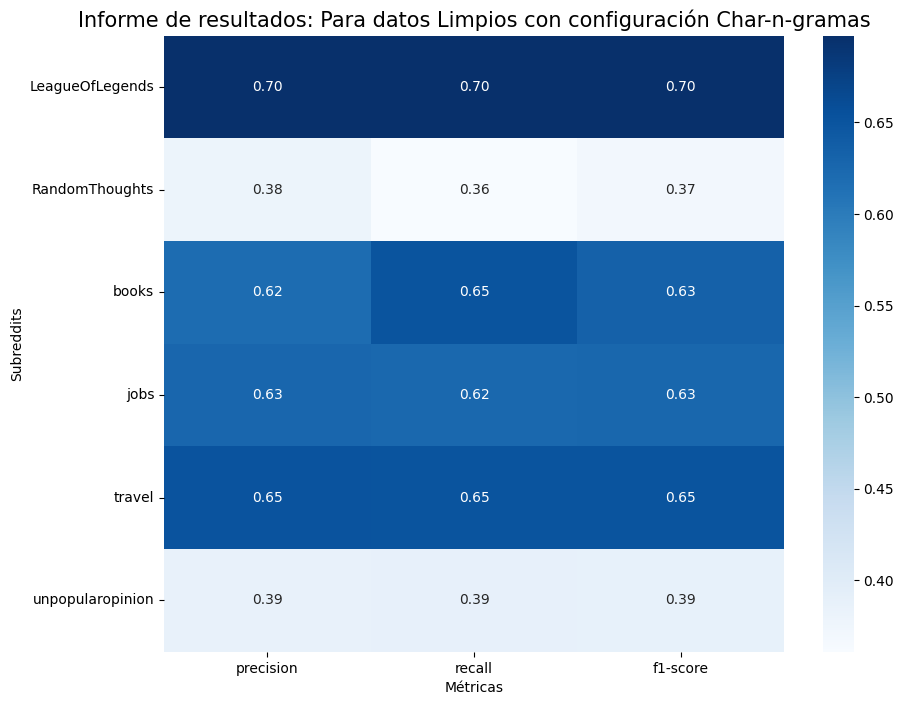

In [ ]:
for (datos, config), diccionario in resultados.items():
	if diccionario["Accuracy"] > 0.5:
		titulo = f"Matriz de confusión: Para datos {datos} con configuración {config}"
		plot_matriz_confusion(diccionario["Matriz de confusión"], titulo, etiquetas)

		titulo = f"Informe de resultados: Para datos {datos} con configuración {config}"
		plot_informe_resultados(diccionario["Informe de resultados"], titulo)

Analizando estos resultados, observamos lo siguiente:

Las configuraciones más efectivas que encontramos son los Unigramas y los Char-n-gramas (3 a 5 caracteres), con diferencia, alcanzando una precisión de entre el $56\%$ y $57\%$.

El uso de Bigramas y Trigramas redujo drásticamente el rendimiento. Esto indica que en textos cortos y diversos como los comentarios, el uso de secuencias largas de palabras genera una matriz demasiado dispersa, lo que dificulta el aprendizaje del modelo.

Sorprendentemente, la limpieza del texto no ha logrado una mejora significativa sobre el texto original. De hecho, en la configuración de Char-n-gramas, el modelo sobre el texto completo fue ligeramente superior con un valor de $0.569$.

Esta base nos sirve para contrastar si los siguientes modelos, capaces de entender el contexto y la semántica, logran superar la precisión del modelo léxico simple.

## FastText

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
!pip install gensim

In [ ]:
import numpy as np

def vectorizar_texto(tokens, modelo, vec_size):
	# Accedemos al valor del vector correspondiente a cada token en caso de que se haya calculado el embedding de esa palabra
	vectores = [modelo.wv[word] for word in tokens if word in modelo.wv]

	# Controlamos el caso vacío, que ninguna palabra esté en el vocabulario o incluso el texto no tenga palabras
	if len(vectores) == 0:
		return np.zeros(vec_size)

	# Obtenemos la media de todas las palabras de una frase
	return np.mean(vectores, axis=0)

In [ ]:
from gensim.models import FastText

# Añadimos una variable para poder iterar sobre ambos conjuntos de entrenamiento y validación de una
datasets = {"Completos": (X_train_completo, X_test_completo),
			"Limpios": (X_train_limpio, X_test_limpio)}

# Añadimos otra variable para poder variar las dimensiones
configuraciones = {
	"FastText 50 dimensiones": 50,
	"FastText 100 dimensiones": 100,
	"FastText 200 dimensiones": 200
}

# Diccionario vacío para guardar todos los resultados y examinarlos más adelante
resultados = {}

# Iteramos por ambos conjuntos de entrenamiento
for datos, (X_train, X_test) in datasets.items():
	print(f"Dataset de datos {datos}\n")

	# Solo es necesario hacerlo una vez para cada conjunto de datos
	X_train_tokens = [word_tokenize(texto) for texto in X_train]
	X_test_tokens = [word_tokenize(texto) for texto in X_test]

	# Ahora iteramos por las configuraciones, creando el modelo correspondiente y mostramos los resultados
	for config, vec_size in configuraciones.items():

		# Entrenar FastText
		modelo_fasttext = FastText(
			sentences=X_train_tokens,
			vector_size=vec_size,
			window=3,      # Distancia máxima entre la palabra predicha y la actual en una frase
			min_count=1,    # Coge todas las palabras
			epochs=10
		)

		# Vectorización
		X_train_vec = [vectorizar_texto(tokens, modelo_fasttext, vec_size) for tokens in X_train_tokens]
		X_test_vec = [vectorizar_texto(tokens, modelo_fasttext, vec_size) for tokens in X_test_tokens]

		# Creamos el clasificador
		clf = LinearSVC(random_state=23, tol=1e-15)
		clf.fit(X_train_vec, y_train)

		y_pred = clf.predict(X_test_vec)

		# Para que salga en formato diccionario y poder convertirlo a DataFrame y visualizarlo
		report = classification_report(y_test, y_pred, output_dict=True)
		matriz = confusion_matrix(y_test, y_pred)
		accuracy = accuracy_score(y_test, y_pred)

		resultados[(datos, config)] = {"Accuracy": accuracy,
										"Informe de resultados": report,
										"Matriz de confusión": matriz,
										}

		print("---------------------------------------------------------\n")
		print(f"Resultados para la configuración {config}")
		print(f"Accuracy = {accuracy}\n")

Dataset de datos Completos

---------------------------------------------------------

Resultados para la configuración FastText 50 dimensiones
Accuracy = 0.324537037037037

---------------------------------------------------------

Resultados para la configuración FastText 100 dimensiones
Accuracy = 0.32731481481481484

---------------------------------------------------------

Resultados para la configuración FastText 200 dimensiones
Accuracy = 0.3226851851851852

Dataset de datos Limpios

---------------------------------------------------------

Resultados para la configuración FastText 50 dimensiones
Accuracy = 0.2986111111111111

---------------------------------------------------------

Resultados para la configuración FastText 100 dimensiones
Accuracy = 0.28935185185185186

---------------------------------------------------------

Resultados para la configuración FastText 200 dimensiones
Accuracy = 0.2810185185185185



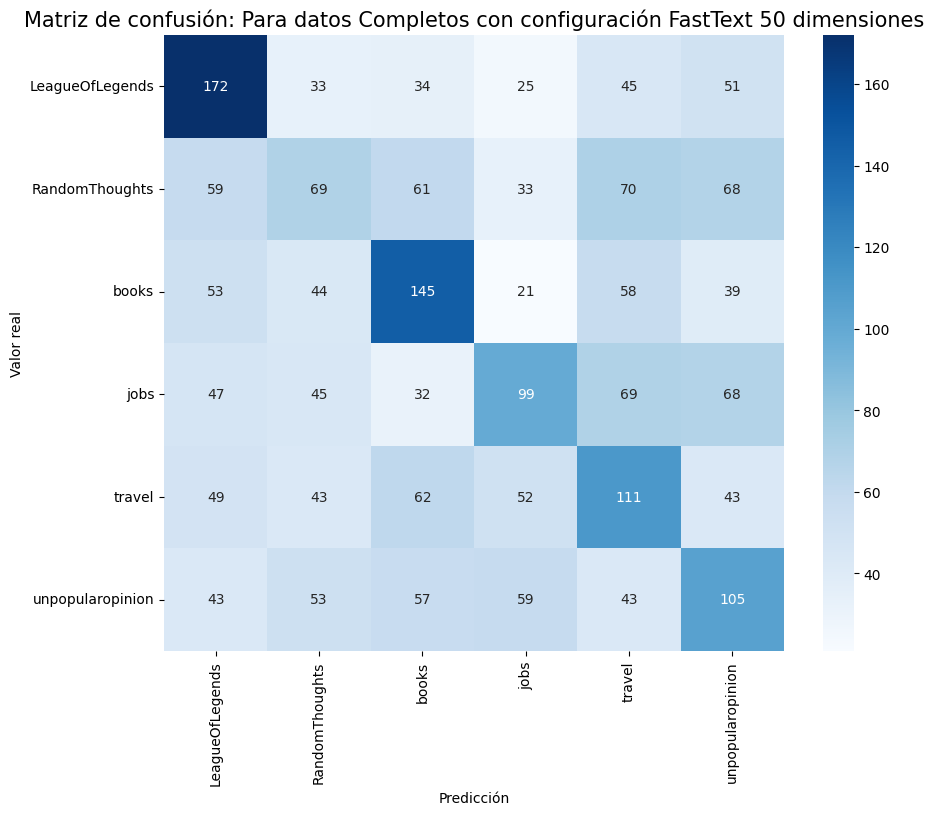

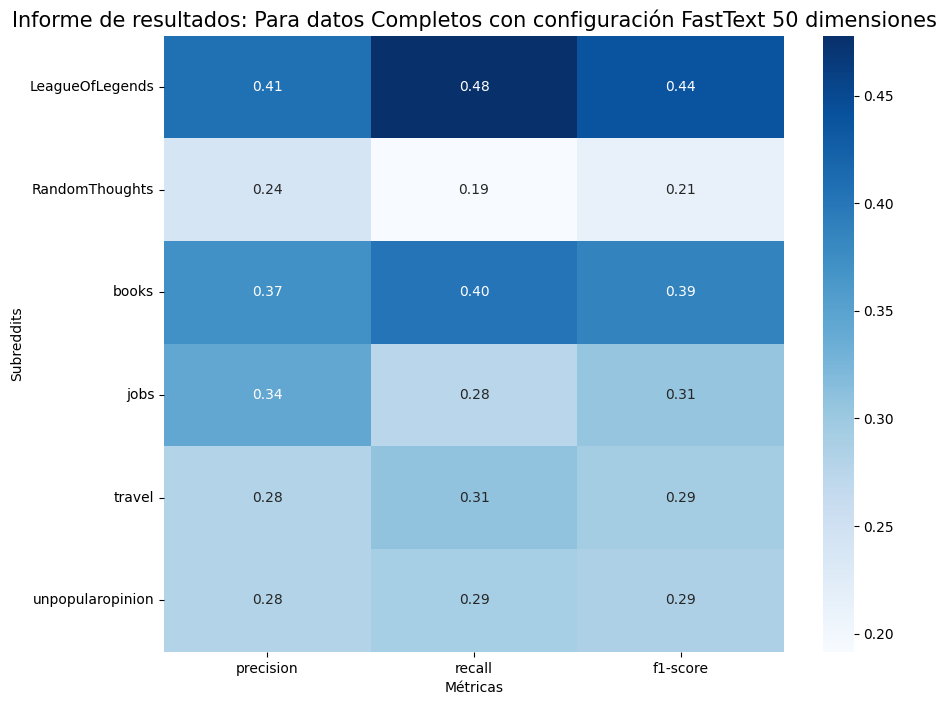

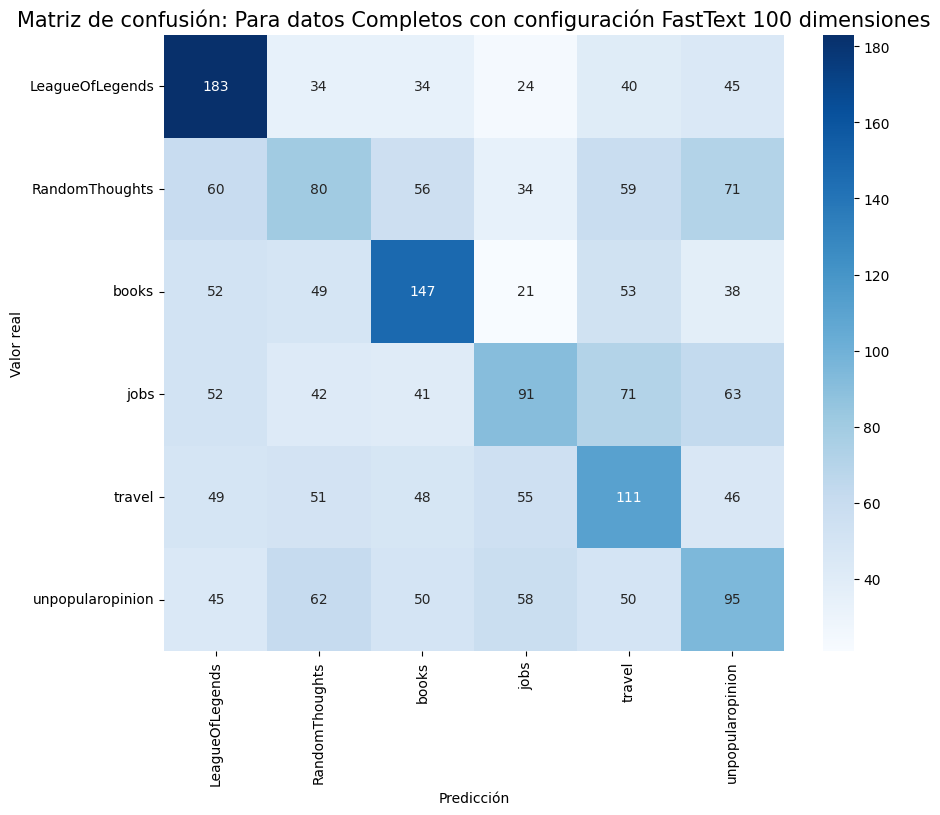

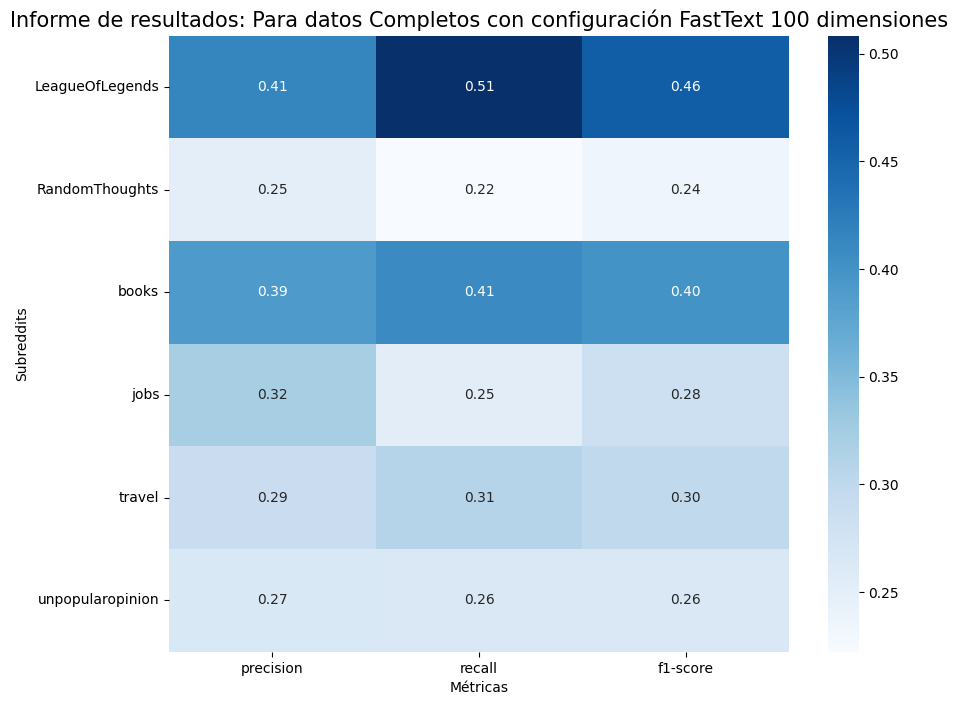

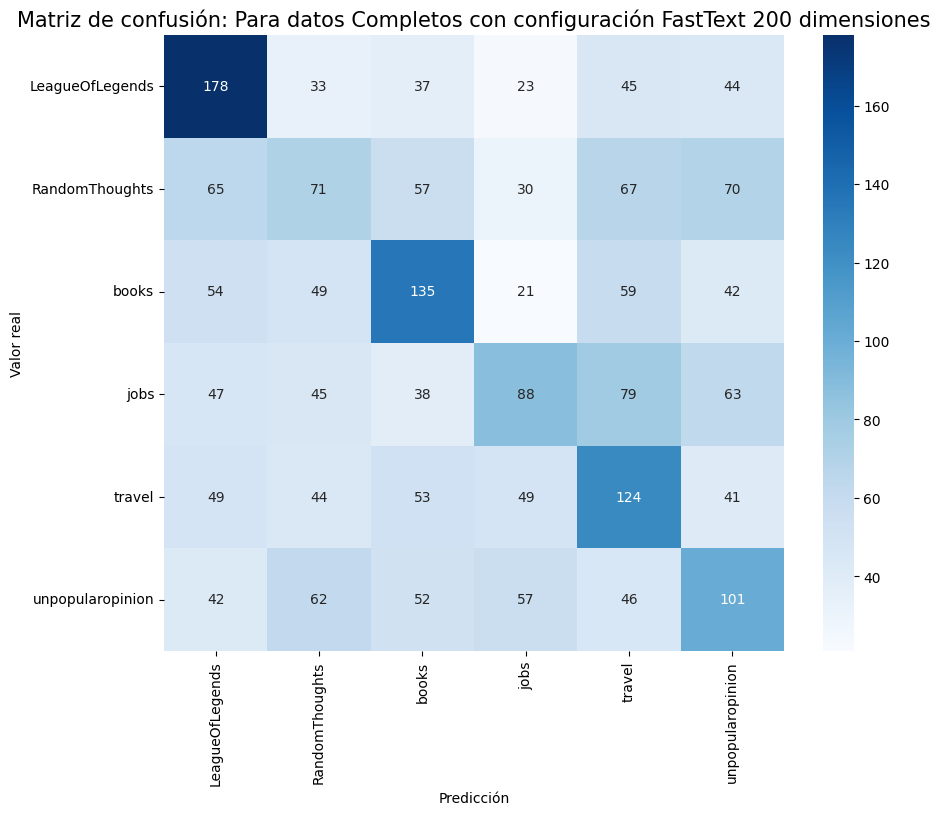

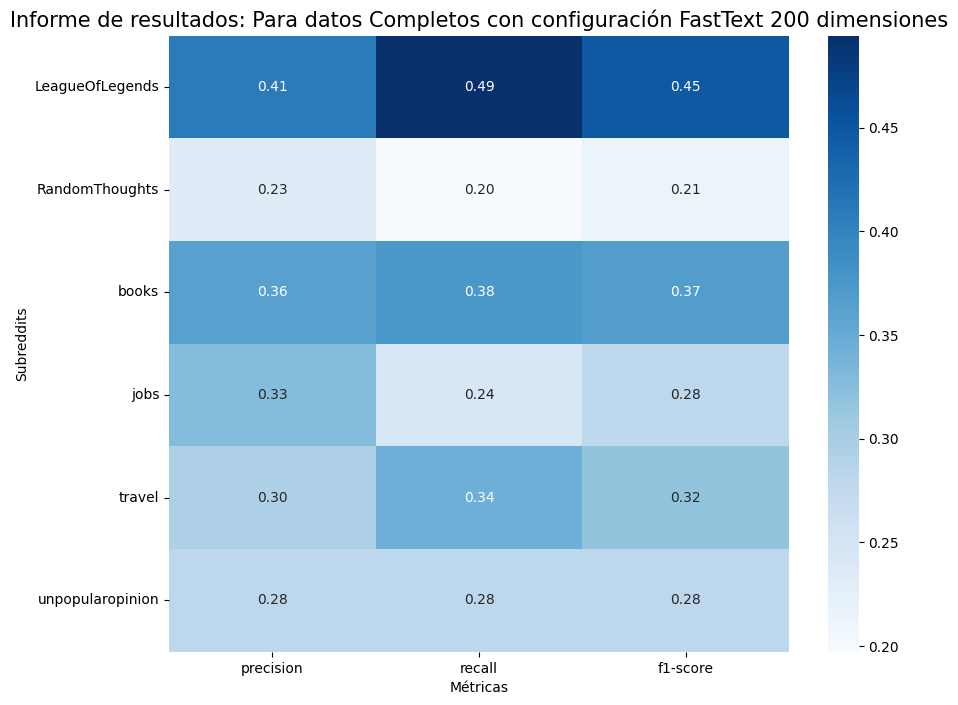

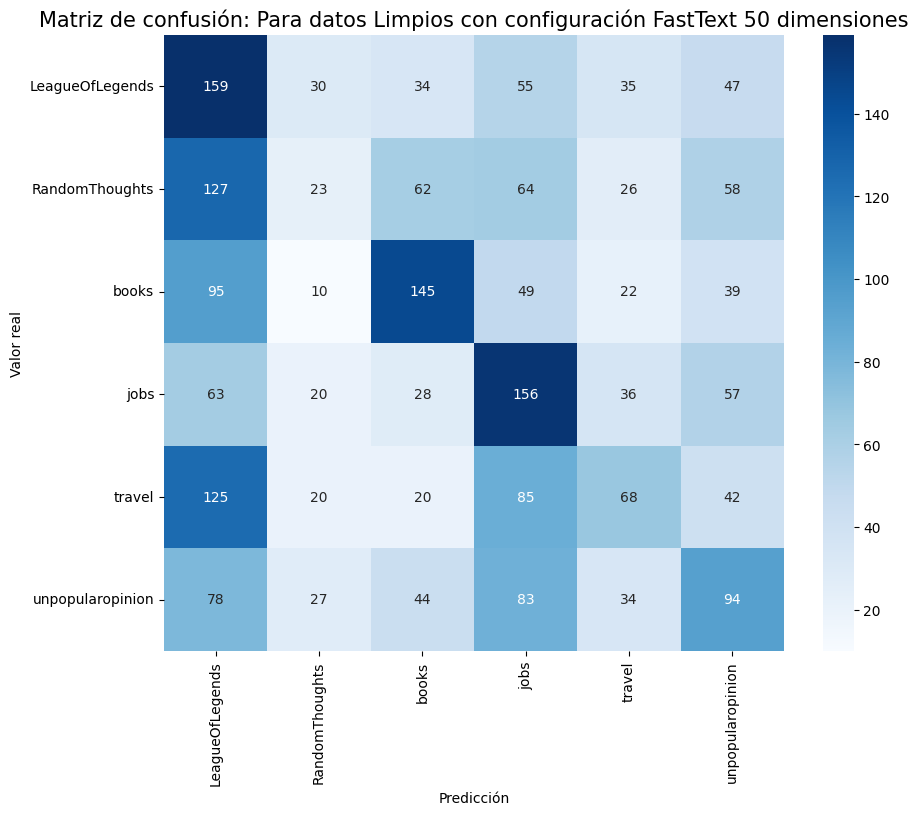

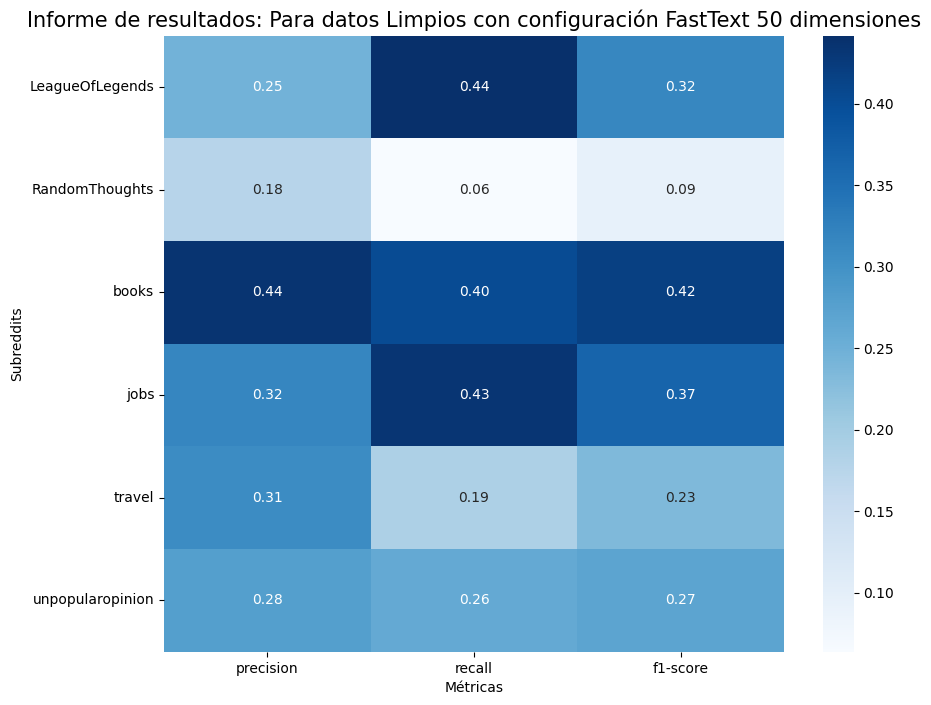

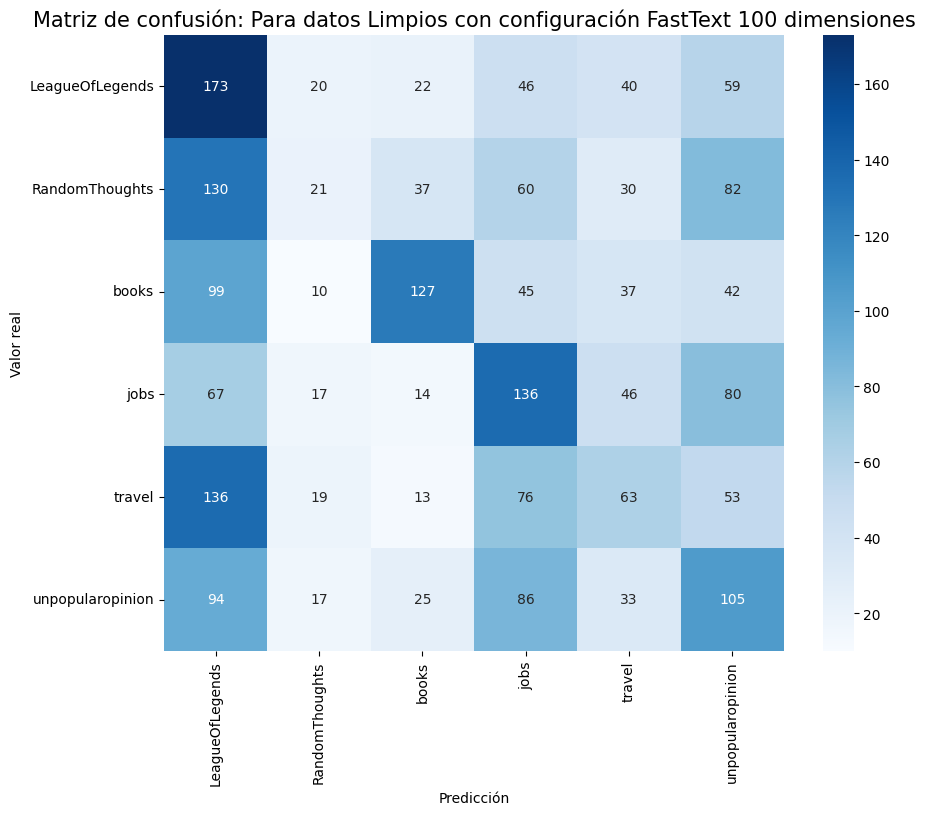

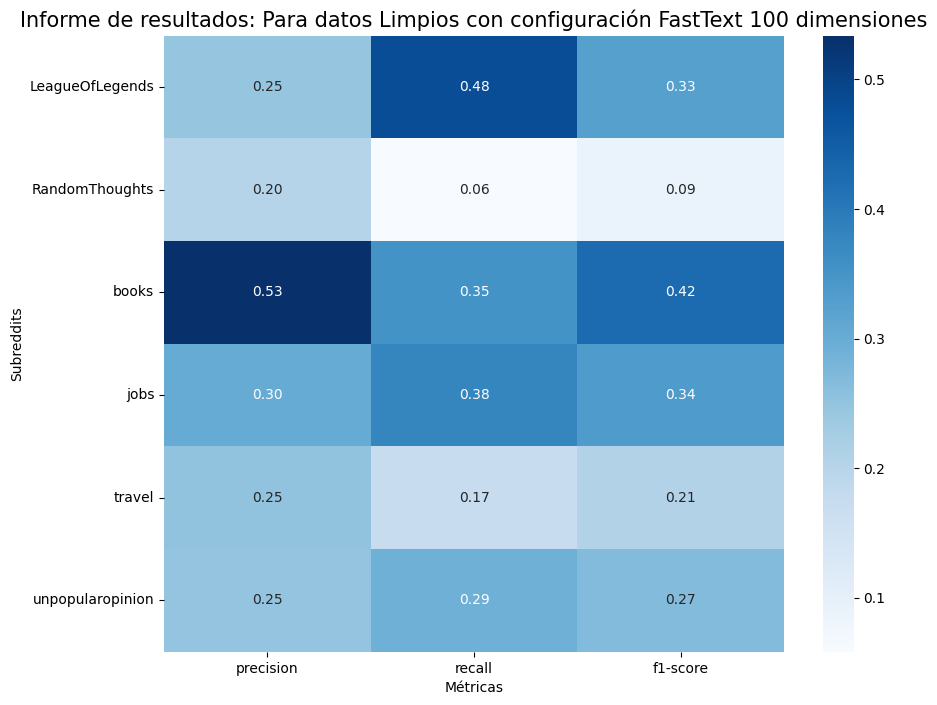

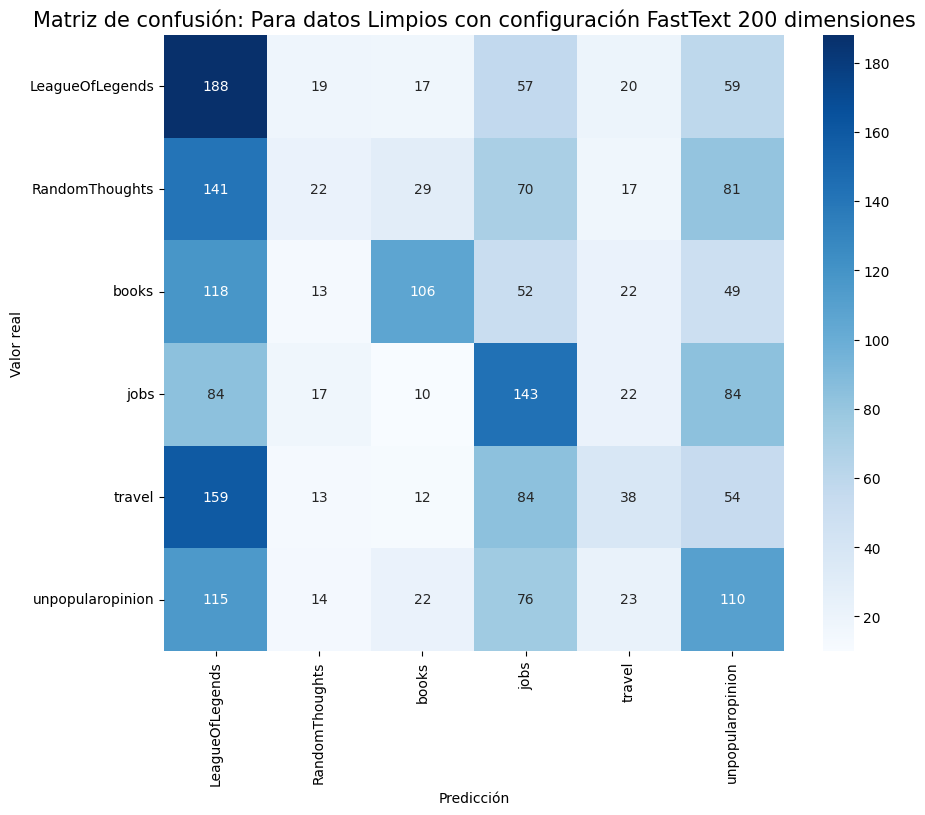

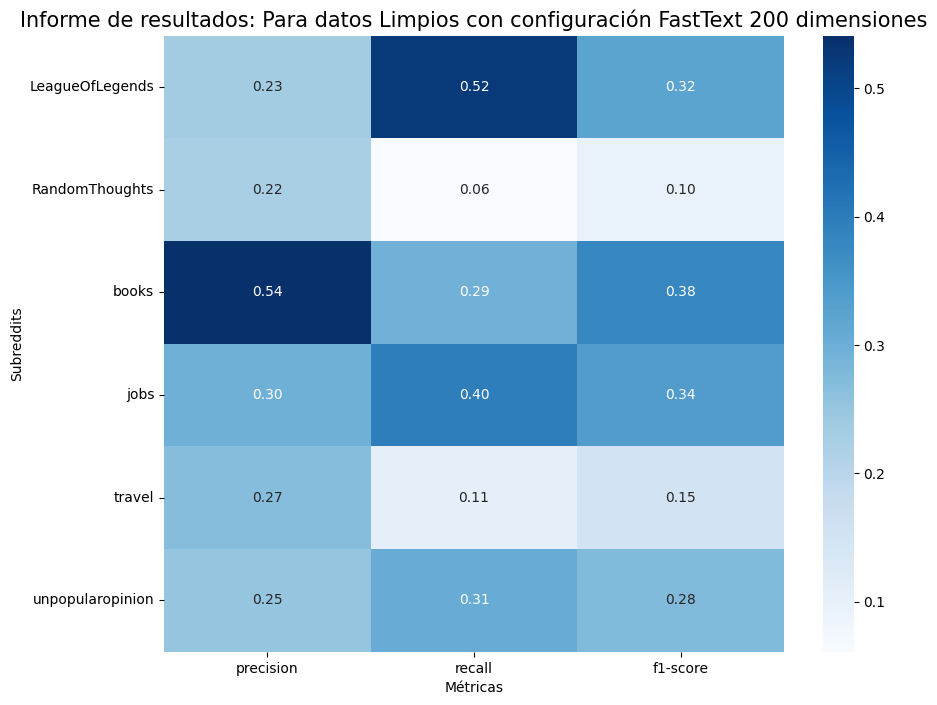

In [ ]:
for (datos, config), diccionario in resultados.items():
	titulo = f"Matriz de confusión: Para datos {datos} con configuración {config}"
	plot_matriz_confusion(diccionario["Matriz de confusión"], titulo, etiquetas)

	titulo = f"Informe de resultados: Para datos {datos} con configuración {config}"
	plot_informe_resultados(diccionario["Informe de resultados"], titulo)

Estos resultados nos muestran dos cosas.

Obtenemos un bajo rendimiento, ha sido el enfoque con los peores resultados, con una precisión máxima de apenas el $32.7\%$.

Además, la técnica de promediar vectores de palabras individuales parece perder demasiada información contextual necesaria para distinguir entre subreddits que comparten vocabulario similar, pero con usos gramaticales o tonos distintos. Al igual que con TF-IDF, el dataset original obtuvo mejores resultados que el preprocesado.

## BERT

Como ya descubrimos en el notebook de [estadisticos](estadisticos.ipynb), el $96.5\%$ del **Corpus** se encuentra escrito en inglés. Este resultado justifica el uso del modelo preentrenado en inglés *BERT-uncased*, ya que la variabilidad lingüística del dataset es mínima.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [ ]:
# En pytorch, los datasets se preparan de manera distinta a Tensorflow
class PLNEDataset(torch.utils.data.Dataset):
	def __init__(self, encodings, labels):
		self.encodings = encodings
		self.labels = labels

	def __getitem__(self, idx):
		item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
		item['labels'] = torch.tensor(self.labels[idx])
		return item

	def __len__(self):
		return len(self.labels)

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
# Fijamos semilla para garantizar reproducibilidad.
SEED = 23
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

############## Definición y carga del modelo ##############

# Al ser siempre los mismos valores, el tokenizador sse extrae del modelo, no depende de nuestros dataos, lo cargamos una unica vez
# Definimos el modelo a utilizar
ruta_modelo = 'bert-base-uncased'

# Cargamos el tokenizer
tokenizer = AutoTokenizer.from_pretrained(ruta_modelo)

# Añadimos una variable para poder iterar sobre ambos conjuntos de entrenamiento y validación de una
datasets = {"Completos": (X_train_completo, X_test_completo),
						"Limpios": (X_train_limpio, X_test_limpio)}

resultados = {}

# Iteramos por ambos conjuntos de entrenamiento
for dataset, (X_train, X_test) in datasets.items():
	print(f"Dataset de datos {dataset}\n")

	# Definimos la traducción de las etiquetas
	labels = sorted(list(set(y_train)))
	id2label = {i: label for i, label in enumerate(labels)}
	label2id = {label: i for i, label in enumerate(labels)}

	# Establecemos el número de etiquetas
	# Vamos a realizar clasificación en nuestros distintos subreddits, por lo tanto el número de etiquetas es 6
	NUM_LABELS = len(labels)

	# Cargamos el modelo (usando pytorch)
	modelo = AutoModelForSequenceClassification.from_pretrained(ruta_modelo,
															 	num_labels=NUM_LABELS)

	# Le pasamos la traducción de las etiquetas al modelo
	modelo.config.id2label = id2label
	modelo.config.label2id = label2id

	############## Preparación de los conjuntos de datos ##############
	df_train = pd.DataFrame({
		"text": X_train,
		"label": y_train
	})
	df_test = pd.DataFrame({
		"text": X_test,
		"label": y_test
	})

	# Codificación
	df_train['_label'] = df_train['label'].apply(lambda x: label2id[x])
	df_test['_label'] = df_test['label'].apply(lambda x : label2id[x])

	# Partimos el conjunto de train en train y evaluación
	df_train, df_eval = train_test_split(df_train, test_size=0.2, random_state=23)

	# Tokenizador
	tokenized_train_dataset = tokenizer(df_train.text.tolist(),  truncation=True, padding = True)
	tokenized_eval_dataset = tokenizer(df_eval.text.tolist(), truncation=True, padding = True)
	tokenized_test_dataset = tokenizer(df_test.text.tolist(), truncation=True, padding = True)

	# Como antes, las etiquetas deben ser numéricas para poder entrenar.
	# Preparamos los 3 datasets para hacer el finetuning
	train_dataset = PLNEDataset(tokenized_train_dataset, df_train._label.tolist())
	eval_dataset = PLNEDataset(tokenized_eval_dataset, df_eval._label.tolist())
	test_dataset = PLNEDataset(tokenized_test_dataset, df_test._label.tolist())

	############## Definición de hiperparámetros de entrenamiento y de trainer ##############

	# Tamaño del batch para entrenamiento
	batch_train_size = 16

	# Tamaño del batch para evaluación
	batch_val_size = 64

	# Métrica usada para elegir el mejor modelo
	metric_name = "eval_f1"

	training_args = TrainingArguments (
		output_dir = f'./results{dataset}', # donde guardar el modelo entrenado
		logging_dir = f'./logs{dataset}', # donde guardar los logs del entrenamiento
		num_train_epochs=3,  # Número de épocas
		eval_strategy="epoch",  # Estrategia de evaluación (epoch / step)
		save_strategy="epoch", # Estrategia de guardado del modelo (epoch / step)
		per_device_train_batch_size = batch_train_size, # Tamaño del batch para entrenamiento
		per_device_eval_batch_size = batch_val_size, # Tamaño del batch para evaluación
		metric_for_best_model=metric_name,  # Métrica usada para elegir el mejor modelo
		save_total_limit=1, # Número máximo de checkpoints a guardar
		load_best_model_at_end=True, # Carga el mejor modelo al final
		report_to="none"  # Desactiva wandb (Weights and Biases)
	)

	# Se encarga de partir el texto en lotes (batches) y añadir el padding necesario
	# Usamos un DataCollatorWithPadding para padding dinámico
	data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

	# Objeto que simplifica el proceso de entrenamiento y evaluación
	trainer = Trainer (
			model = modelo, # modelo
			args = training_args, # hiperparámetros de entreamiento
			train_dataset = train_dataset, # conjunto de train
			eval_dataset = eval_dataset, # conjunto de evaluacion
			data_collator=data_collator,
			compute_metrics=compute_metrics)

	############## Entrenamiento del modelo ##############
	trainer.train()

	# Predicción
	predictions = trainer.predict(test_dataset)

	y_pred = np.argmax(predictions.predictions, axis=1)
	y_true = df_test["_label"].values

	# Para que salga en formato diccionario y poder convertirlo a DataFrame y visualizarlo
	report = classification_report(y_true, y_pred, output_dict=True)
	matriz = confusion_matrix(y_true, y_pred)
	accuracy = accuracy_score(y_true, y_pred)

	resultados[dataset] = {"Accuracy": accuracy,
									"Informe de resultados": report,
									"Matriz de confusión": matriz,
									}

	print("---------------------------------------------------------\n")
	print(f"Accuracy = {accuracy}\n")


Dataset de datos Completos



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,F1
1,No log,0.811198,0.710089
2,No log,0.699453,0.760406
3,0.752135,0.718453,0.781207


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

---------------------------------------------------------

Accuracy = 0.65



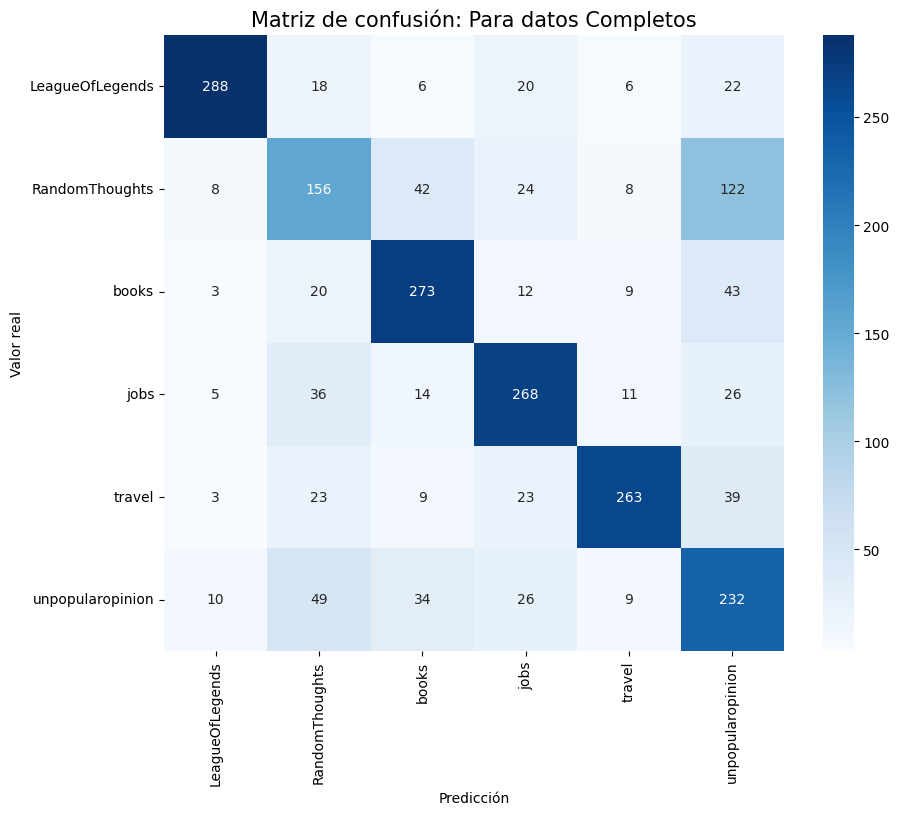

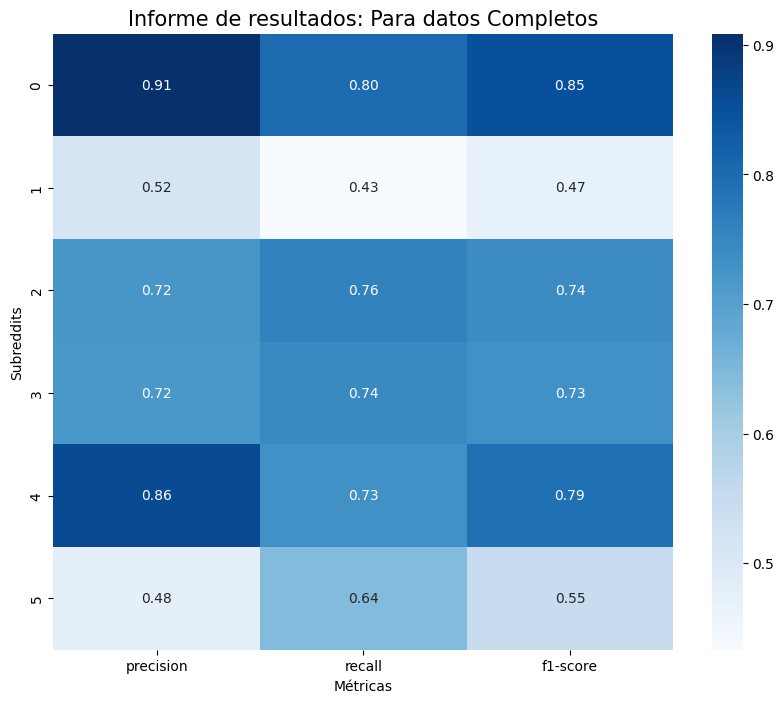

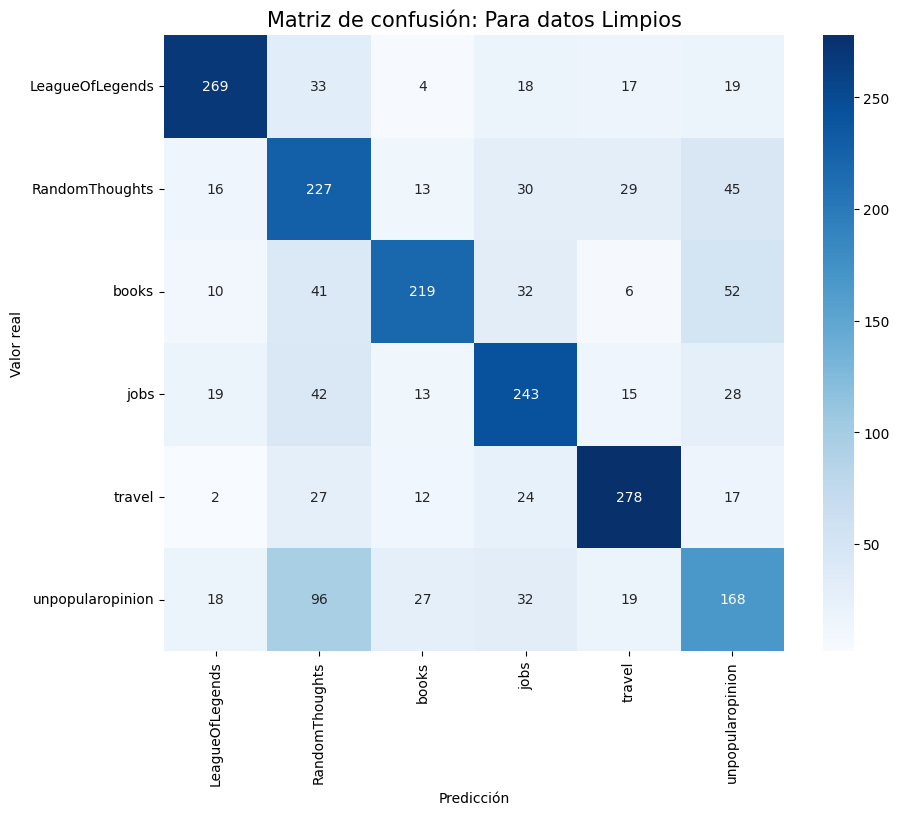

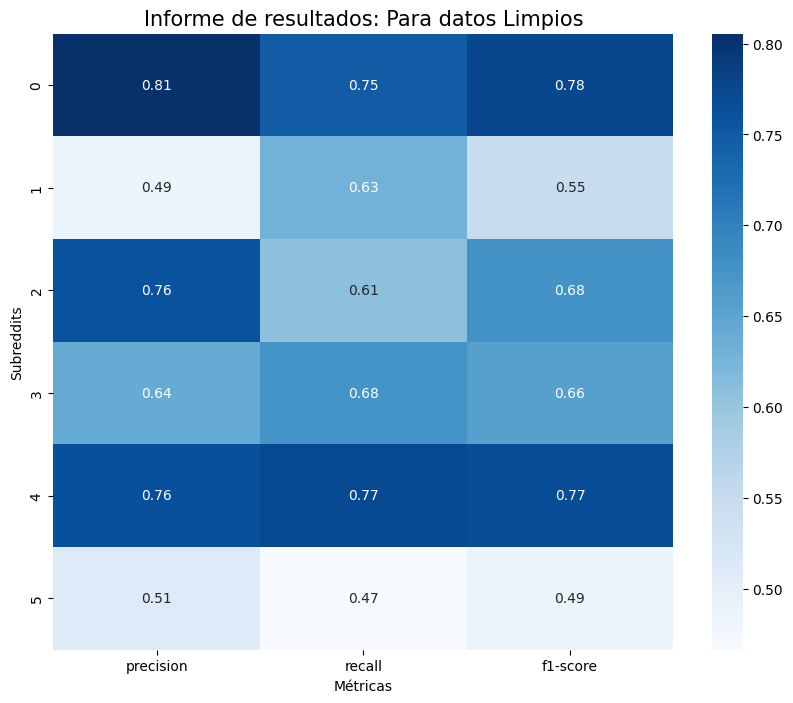

In [ ]:
for datos, diccionario in resultados.items():
	titulo = f"Matriz de confusión: Para datos {datos}"
	plot_matriz_confusion(diccionario["Matriz de confusión"], titulo, etiquetas)

	titulo = f"Informe de resultados: Para datos {datos}"
	plot_informe_resultados(diccionario["Informe de resultados"], titulo)

Este modelo es con diferencia el que mejor rendimiento ofrece, logrando una precisión del $68.5\%$ en el dataset completo.

Analizando el entrenamiento, vemos que durante las 3 épocas, se observa una mejora constante en la métrica F1, lo que demuestra que el modelo es capaz de extraer patrones profundos de las etiquetas de los subreddits.

Al igual que en los casos anteriores, el rendimiento en el dataset "Limpio" fue inferior al "Completo". Esto confirma que los modelos basados en Transformers aprovechan elementos del texto original que los preprocesados eliminan.

## Conclusión final

Tras completar la comparativa entre los tres sistemas, se pueden extraer varias conclusiones relevantes sobre el rendimiento de los modelos y el impacto del preprocesamiento en la tarea de clasificación.

*   **Resultados consistentes**: De forma general, se observa que en los tres enfoques los subreddits **r/RandomThoughts** y **r/unpopularopinion** son los más difíciles de clasificar. Ambos presentan de forma recurrente las tasas de acierto más bajas y una alta confusión entre sí. Este comportamiento es esperable, ya que el contenido de ambas comunidades es muy similar en naturaleza: un “pensamiento aleatorio” puede solaparse fácilmente con una “opinión poco popular”, lo que dificulta la separación clara entre clases.

*   **Comparativa de Modelos**: En cuanto al rendimiento global, el modelo basado en Transformers obtiene los mejores resultados, alcanzando una precisión del 68.5%. Esto se debe a su capacidad para modelar el contexto completo de las frases y capturar relaciones semánticas complejas, lo que resulta especialmente útil en el lenguaje informal y variable de Reddit.

En el extremo opuesto, el modelo basado en Word Embeddings (FastText) presenta el peor rendimiento, con una precisión del 32.7%. Este resultado se explica porque la representación mediante promedios de vectores densos no es suficientemente expresiva para capturar matices semánticos finos ni diferencias entre comunidades con vocabulario similar.

Finalmente, el modelo basado en TF-IDF + Linear SVC se sitúa como una solución intermedia, pero muy sólida, alcanzando aproximadamente un 57% de accuracy. Este enfoque, basado en la frecuencia de términos y n-gramas tanto de palabras como de caracteres, demuestra que las representaciones léxicas tradicionales siguen siendo altamente efectivas en tareas de clasificación de texto corto, especialmente como baseline frente a modelos más complejos.

*   **Utilidad del preprocesamiento**: En base a los resultados obtenidos, se concluye que el preprocesamiento aplicado (eliminación de stopwords y ruido) no ha supuesto una mejora significativa en el rendimiento de los modelos. En algunos casos incluso se observa una ligera degradación, lo que sugiere que cierta información superficial del texto puede ser útil para la tarea de clasificación.

En resumen, mientras que la estadística simple de **TF-IDF** es suficiente para un primer filtrado, solo los modelos de **Transformers** logran capturar la complejidad semántica necesaria para clasificar correctamente el lenguaje natural de estos subreddits.